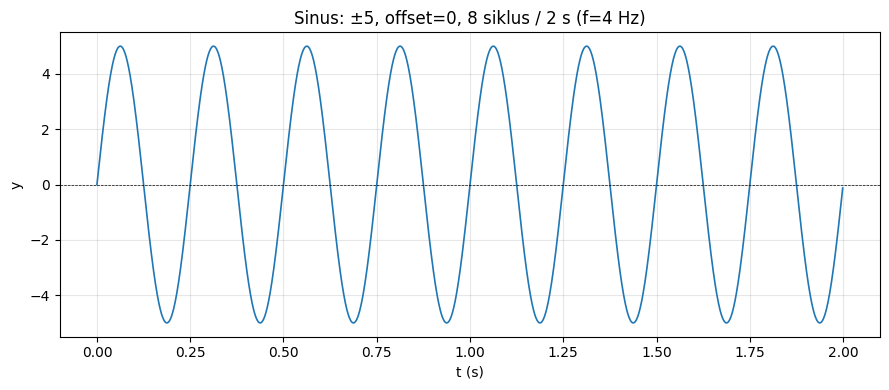

In [3]:
import numpy as np
import matplotlib.pyplot as plt

A = 5.0  # amplitudo puncak: y berkisar di [-A, +A]
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
y = A * np.sin(2 * np.pi * f * t)  # tanpa offset (DC = 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus: ±{A:g}, offset=0, {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A * 1.1, A * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

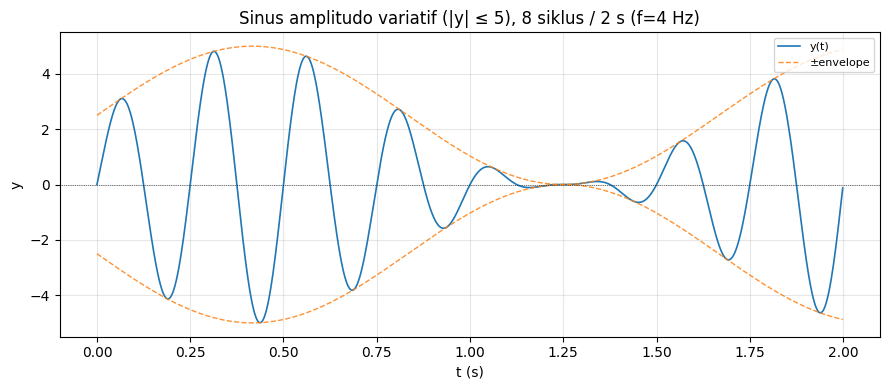

In [4]:
"""
Sinus amplitudo variatif — modulasi amplitudo (AM).

Idea:
- Carrier: sin(2*pi*f*t), nilai di [-1, 1].
- Envelope: (A_max/2) * (1 + sin(2*pi*f_env*t)), selalu di [0, A_max].
- Sinyal: y(t) = envelope(t) * carrier(t).

Batas |y| <= A_max:
Karena |carrier| <= 1, maka |y(t)| <= envelope(t) <= A_max.
Saat sin(...)=-1 envelope=0; saat sin(...)=+1 envelope=A_max.

Parameter:
- f_env: laju variasi amplop (Hz), biasanya lebih kecil dari f carrier.
- f, n_cycles, T, fs: sama konsepnya dengan sel 0 (jumlah siklus carrier dalam T).
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
# Envelope amplitudo variatif dalam [0, A_max] → |envelope * sin| ≤ A_max
f_env = 0.6  # frekuensi modulasi amplitudo (Hz), lebih rendah dari carrier
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
carrier = np.sin(2 * np.pi * f * t)
y = envelope * carrier  # tanpa offset DC pada carrier; envelope bermean >0 tapi y tetap |y|≤A_max

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2, label="y(t)")
ax.plot(t, envelope, color="C1", lw=1.0, ls="--", alpha=0.85, label="±envelope")
ax.plot(t, -envelope, color="C1", lw=1.0, ls="--", alpha=0.85)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus amplitudo variatif (|y| ≤ {A_max:g}), {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A_max * 1.1, A_max * 1.1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()